### Structured output
Models can be requested to provide their response in a format matching a given schema. This is useful for ensuring the output can be easily parsed and used in subsequent processing. LangChain supports multiple schema types and methods for enforcing structured output.

### Pydantic
Pydantic models provide the richest feature set with field validation, descriptions, and nested structures.

In [6]:
import os
from langchain.chat_models import init_chat_model
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
model=init_chat_model("groq:qwen/qwen3-32b")
model

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x112585590>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1125821d0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [7]:
from pydantic import BaseModel,Field

class Movie(BaseModel):
    title:str=Field(description="The title of the movie")
    year:int=Field(description="This year the movie was released")
    director:str=Field(description="The director of the movie")
    rating:float=Field(description="The movies rating out of 10")

In [8]:
model_with_structure=model.with_structured_output(Movie)
model_with_structure

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x112585590>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1125821d0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'Movie', 'description': '', 'parameters': {'properties': {'title': {'description': 'The title of the movie', 'type': 'string'}, 'year': {'description': 'This year the movie was released', 'type': 'integer'}, 'director': {'description': 'The director of the movie', 'type': 'string'}, 'rating': {'description': 'The movies rating out of 10', 'type': 'number'}}, 'required': ['title', 'year', 'director', 'ra

In [10]:
response = model.invoke("Provide details about the movie Inception")
response

AIMessage(content='<think>\nOkay, so I need to provide details about the movie Inception. Let me start by recalling what I know. Inception is a 2010 science fiction action film directed by Christopher Nolan. The main plot revolves around a thief who enters people\'s dreams to steal secrets. The protagonist is Dom Cobb, played by Leonardo DiCaprio. His character uses a device called a totem to confirm whether he\'s in reality or in a dream. The film has a complex narrative with multiple layers of dreams within dreams. There\'s a team that enters a target\'s subconscious to plant an idea, which is called "inception." \n\nI remember that the movie has a lot of action scenes, some of which are visually stunning, like the rotating hallway fight scene. The cast includes Tom Hardy, Joseph Gordon-Levitt, and Ellen Page. The music is by Hans Zimmer, and the score is quite memorable. The film explores themes like reality vs. dreams, the power of the subconscious, and the concept of time. It\'s k

In [11]:
response = model_with_structure.invoke("Provide details about the movie Inception")
response

Movie(title='Inception', year=2010, director='Christopher Nolan', rating=8.8)

### Message ouput alongside Parsed Structure

In [12]:
from pydantic import BaseModel,Field

class Movie(BaseModel):
    title:str=Field(description="The title of the movie")
    year:int=Field(description="This year the movie was released")
    director:str=Field(description="The director of the movie")
    rating:float=Field(description="The movies rating out of 10")


model_with_structure=model.with_structured_output(Movie, include_raw=True)

response = model_with_structure.invoke("Provide details about the movie Inception")
response

{'raw': AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user is asking for details about the movie Inception. Let me check the tools provided. There's a Movie function that requires title, year, director, and rating. I need to fill those parameters. I know Inception was directed by Christopher Nolan. It came out in 2010. The rating is probably around 8.8 on IMDb. Let me confirm the exact year and rating. Yep, 2010 and 8.8. So I'll structure the tool call with those details.\n", 'tool_calls': [{'id': 'p7yjs8b1y', 'function': {'arguments': '{"director":"Christopher Nolan","rating":8.8,"title":"Inception","year":2010}', 'name': 'Movie'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 157, 'prompt_tokens': 225, 'total_tokens': 382, 'completion_time': 0.265931792, 'completion_tokens_details': {'reasoning_tokens': 109}, 'prompt_time': 0.009927584, 'prompt_tokens_details': None, 'queue_time': 0.049771436, 'total_time': 0.275859376}, 'mo

### Nested Structure

In [ ]:
from pandas.core.dtypes.dtypes import str_type
from pydantic import BaseModel, Field

class Actor(BaseModel):
    name:str
    role:str

class MovieDetails(BaseModel):
    title:str
    year:int
    cast:list[Actor]
    generes:list[str]
    budget:float | None = Field(None, description="budget in millions USD")

model_with_structure=model.with_structured_output(MovieDetails)

response = model_with_structure.invoke("Provide details about the movie Inception")
response

MovieDetails(title='Inception', year=2010, cast=[Actor(name='Leonardo DiCaprio', role='Dom Cobb'), Actor(name='Joseph Gordon-Levitt', role='Arthur'), Actor(name='Ellen Page', role='Ariadne'), Actor(name='Tom Hardy', role='Eames'), Actor(name='Ken Watanabe', role='Saito')], generes=['Action', 'Sci-Fi', 'Thriller'], budget=160.0)

### TypedDict
TypedDict provides a simpler alternative using Python’s built-in typing, ideal when you don’t need runtime validation.

In [16]:
from typing_extensions import TypedDict, Annotated


class MovieDict(TypedDict):
    """ A movie with details."""
    title:Annotated[str, ..., "The title of the movies"]
    year:Annotated[int, ..., "The year the movie was released"]
    director: Annotated[str, ..., "The director of the movie"]
    rating:Annotated[float, ..., "The movie's rating out of 10"]

model_with_type_dict = model.with_structured_output(MovieDict)
response = model_with_type_dict.invoke("Provide details about the movie Avengers")

In [17]:
response

{'director': 'Joss Whedon', 'rating': 8, 'title': 'Avengers', 'year': 2012}

In [18]:
class Actor(TypedDict):
    name:str
    role:str

class MovieDetails(TypedDict):
    title:str
    year:int
    cast:list[Actor]
    generes:list[str]
    budget:float | None = Field(None, description="budget in millions USD")

model_with_structure=model.with_structured_output(MovieDetails)

response = model_with_structure.invoke("Provide details about the movie Inception")
response

{'budget': 160000000,
 'cast': [{'name': 'Leonardo DiCaprio', 'role': 'Dom Cobb'},
  {'name': 'Joseph Gordon-Levitt', 'role': 'Arthur'},
  {'name': 'Ellen Page', 'role': 'Ariadne'},
  {'name': 'Tom Hardy', 'role': 'Balthazar'}],
 'generes': ['Action', 'Sci-Fi', 'Thriller'],
 'title': 'Inception',
 'year': 2010}

In [19]:
class Actor(TypedDict):
    name:str
    role:str

class MovieDetails(TypedDict):
    title:str
    year:int
    cast:list[Actor]
    generes:list[str]
    budget:float | None = Field(None, description="budget in millions USD")

model_with_structure=model.with_structured_output(MovieDetails)

response = model_with_structure.invoke("Provide details about the movie Avengers")
response

{'budget': 220000000,
 'cast': [{'name': 'Robert Downey Jr.', 'role': 'Tony Stark / Iron Man'},
  {'name': 'Chris Evans', 'role': 'Steve Rogers / Captain America'},
  {'name': 'Mark Ruffalo', 'role': 'Bruce Banner / Hulk'},
  {'name': 'Chris Hemsworth', 'role': 'Thor'},
  {'name': 'Scarlett Johansson', 'role': 'Natasha Romanoff / Black Widow'},
  {'name': 'Jeremy Renner', 'role': 'Clint Barton / Hawkeye'}],
 'generes': ['Action', 'Science Fiction', 'Adventure'],
 'title': 'Avengers',
 'year': 2012}

In [20]:
model_with_structure.profile

AttributeError: 'RunnableSequence' object has no attribute 'profile'

In [21]:
model.profile

{'max_input_tokens': 131072,
 'max_output_tokens': 16384,
 'image_inputs': False,
 'audio_inputs': False,
 'video_inputs': False,
 'image_outputs': False,
 'audio_outputs': False,
 'video_outputs': False,
 'reasoning_output': True,
 'tool_calling': True}

### DataClasses
A data class is a class typically containing mainly data, although there aren’t really any restrictions. You create it using the @dataclass decorator

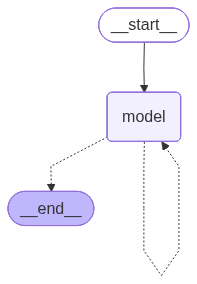

In [2]:
import os
from pydantic import BaseModel, Field
from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")


class ContactInfo(BaseModel):
    """Contact information for a person"""
    name:str = Field(description="The name of the person")
    email:str= Field(description="The email address of the person")
    phone:str= Field(description="The phone number of the person")

model = ChatGoogleGenerativeAI(model ="gemini-2.5-flash-lite")
agent = create_agent(
    model = model,
    response_format=ContactInfo   # Auto-selects Provider Strategy
)
agent


In [3]:
result = agent.invoke({
    "messages": [{"role":"user",
    "content": "Extract contact info from: John Doe, john@example.com, (555) 123-4567"}]
})
result

{'messages': [HumanMessage(content='Extract contact info from: John Doe, john@example.com, (555) 123-4567', additional_kwargs={}, response_metadata={}, id='557c316f-7fd5-4bd3-b89e-e42f47f3e652'),
  AIMessage(content='{\n  "name": "John Doe",\n  "email": "john@example.com",\n  "phone": "(555) 123-4567"\n}', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019c12b4-385b-70f2-8595-63e5836cb8b3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 29, 'output_tokens': 44, 'total_tokens': 73, 'input_token_details': {'cache_read': 0}})],
 'structured_response': ContactInfo(name='John Doe', email='john@example.com', phone='(555) 123-4567')}

In [4]:
result['structured_response']

ContactInfo(name='John Doe', email='john@example.com', phone='(555) 123-4567')

## Using type dict

In [8]:
import os
from typing_extensions import TypedDict
from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")


class ContactInfo(TypedDict):
    """Contact information for a person"""
    name:str #The name of the person
    email:str #The email address of the person
    phone:str #The phone number of the person

model = ChatGoogleGenerativeAI(model ="gemini-2.5-flash-lite")
agent = create_agent(
    model = model,
    response_format=ContactInfo   # Auto-selects Provider Strategy
)
result = agent.invoke({
    "messages": [{"role":"user",
    "content": "Extract contact info from: John Doe, john@example.com, (555) 123-4567"}]
})
result['structured_response']

{'name': 'John Doe', 'email': 'john@example.com', 'phone': '(555) 123-4567'}

In [9]:
## Data Classes

from dataclasses import dataclass
from langchain.agents import create_agent
@dataclass
class ContactInfo:
    """Contact information for a person"""

    name:str #The name of the person
    email:str #The email address of the person
    phone:str #The phone number of the person

model = ChatGoogleGenerativeAI(model ="gemini-2.5-flash-lite")
agent = create_agent(
    model = model,
    response_format=ContactInfo   # Auto-selects Provider Strategy
)

result = agent.invoke({
    "messages": [{"role":"user",
    "content": "Extract contact info from: John Doe, john@example.com, (555) 123-4567"}]
})
result['structured_response']


ContactInfo(name='John Doe', email='john@example.com', phone='(555) 123-4567')